# Entrenamiento modelo predicción de seniority

In [33]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/interim/df_merged.csv')
df = df.dropna(subset=['experiencia'])
df.drop(columns=['Rango_Salarial','años_experiencia','modalidad','beneficios'], inplace=True) # no elimino salario medio para eliminar outliers de salario e intern
df = df.drop(index=df[df['tipo_de_empleo'] == 'Voluntariado'].index)
df = df.drop(index=df[df['sector'] == 'Bienes raíces'].index)

In [34]:
df.shape

(19929, 7)

In [35]:
df['experiencia'].value_counts()

experiencia
junior    7174
intern    6831
senior    5924
Name: count, dtype: int64

In [36]:
df['experiencia'] = df['experiencia'].replace({'intern': 0, 'junior': 1, 'senior': 2})

In [37]:
df.head()

,experiencia,formación_académica,sector,tipo_de_empleo,Ciudad,Salario_medio,Titulo_Habilidades
0,1,Grado Universitario,"Salud, Farmacia y Tecnología Médica",Media jornada,Madrid,25000.0,FISIOTERAPEUTA NEUROLÓGICO Fisioterapia neurol...
1,1,Ninguna,Servicios,Jornada completa,Madrid,43200.0,Comercial puerta fría - Sector banca digital C...
2,1,Grado Universitario,Economía y política,Jornada completa,Madrid,13200.0,"Profesora/a de Lengua 2ºESO Profesor, enseñanz..."
3,2,Ninguna,Transporte y Logística,NaN,Madrid,131112.0,"Direct Entry Captain - Pilot Piloto, experienc..."
4,0,Ninguna,Economía y política,Jornada completa,Madrid,15144.0,Promotor/a - Encuestador/a de Educación comuni...


Antes de separar en X e y, voy a eliminar salarios superiores a 20.000€ de intern, como hice en el EDA, ya que no son salarios realistas para unas prácticas y estropean los modelos. Lo hago antes de separar en x e y ya que en y está la variable de si es intern o no y en x el salario.

In [38]:
df = df[~((df['experiencia'] == 0) & (df['Salario_medio'] > 20000))]

In [39]:
df.shape

(18196, 7)

In [40]:
df.drop(columns=['Salario_medio'], inplace=True)

## 1. Declarar X e y

In [41]:
X = df.drop(columns=['experiencia'])
y = df['experiencia']

## 2. Dividir en train y test

In [42]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 3. Feature Engineering

### Valores faltantes

In [43]:
X_train.isnull().sum()

formación_académica       0
sector                    0
tipo_de_empleo         4398
Ciudad                   13
Titulo_Habilidades        0
dtype: int64

Por ahora voy a mantener los nulos, ya que modelos como XGBoost o Random Forest pueden trabajar con valores nulos.

### Encode variables categoricas

In [44]:
X_train[['formación_académica','sector','tipo_de_empleo','Ciudad']]

,formación_académica,sector,tipo_de_empleo,Ciudad
21109,Postgrado,Internet,NaN,Jaén
19508,ESO,"Viajes, turismo y hostelería",Contrato por obra,Málaga
6459,FP Superior,Comercio minorista y comercio,Jornada completa,Toledo
4534,FP Superior,Servicios,Jornada completa,España
12882,Ninguna,Servicios,Jornada completa,Jerez de la Frontera
...,...,...,...,...
36005,Ninguna,Tecnología y telecomunicaciones,NaN,Madrid
22000,Ninguna,Servicios,NaN,Madrid
10874,Grado Universitario,"Salud, Farmacia y Tecnología Médica",Jornada completa,Badajoz
13288,Grado Universitario,Internet,Jornada completa,Tarragona


In [45]:
pd.get_dummies(X_train['formación_académica'], prefix='formacion', drop_first=True, dummy_na=True).astype(int).head()

,formacion_FP Medio,formacion_FP Superior,formacion_Grado Universitario,formacion_Ninguna,formacion_Postgrado,formacion_nan
21109,0,0,0,0,1,0
19508,0,0,0,0,0,0
6459,0,1,0,0,0,0
4534,0,1,0,0,0,0
12882,0,0,0,1,0,0


In [46]:
pd.get_dummies(X_train['sector'], prefix='sector', drop_first=True).astype(int).head()

,sector_Bienes de consumo,sector_Comercio electrónico,sector_Comercio minorista y comercio,sector_Construcción,sector_Deportes y recreación,sector_Economía y política,sector_Energía y medio ambiente,sector_Finanzas y seguros,sector_Internet,sector_Medios de comunicación,sector_Metales y electrónica,sector_Productos químicos y recursos,sector_Publicidad y Marketing,"sector_Salud, Farmacia y Tecnología Médica",sector_Servicios,sector_Sociedad,sector_Tecnología y telecomunicaciones,sector_Transporte y Logística,"sector_Viajes, turismo y hostelería"
21109,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
19508,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
6459,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4534,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
12882,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


In [47]:
pd.get_dummies(X_train['tipo_de_empleo'], prefix='tipo_empleo', drop_first=True, dummy_na=True).astype(int).head()

,tipo_empleo_Jornada completa,tipo_empleo_Media jornada,tipo_empleo_Otro,tipo_empleo_Prácticas,tipo_empleo_Temporal,tipo_empleo_nan
21109,0,0,0,0,0,1
19508,0,0,0,0,0,0
6459,1,0,0,0,0,0
4534,1,0,0,0,0,0
12882,1,0,0,0,0,0


In [48]:
X_train = pd.concat([X_train.drop(columns=['formación_académica','sector','tipo_de_empleo','Ciudad']),
                     pd.get_dummies(X_train['formación_académica'], prefix='formacion', drop_first=True, dummy_na=True).astype(int),
                     pd.get_dummies(X_train['sector'], prefix='sector', drop_first=True).astype(int),
                     pd.get_dummies(X_train['tipo_de_empleo'], prefix='tipo_empleo', drop_first=True, dummy_na=True).astype(int)], axis=1)

In [49]:
X_train.head()

,Titulo_Habilidades,formacion_FP Medio,formacion_FP Superior,formacion_Grado Universitario,formacion_Ninguna,formacion_Postgrado,formacion_nan,sector_Bienes de consumo,sector_Comercio electrónico,sector_Comercio minorista y comercio,...,sector_Sociedad,sector_Tecnología y telecomunicaciones,sector_Transporte y Logística,"sector_Viajes, turismo y hostelería",tipo_empleo_Jornada completa,tipo_empleo_Media jornada,tipo_empleo_Otro,tipo_empleo_Prácticas,tipo_empleo_Temporal,tipo_empleo_nan
21109,"Machine Learning Engineer Python, Frameworks p...",0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
19508,"27973 - Técnico/a de infra y vía Ventas, Atenc...",0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
6459,"Técnico Comercial negociación, habilidades de ...",0,1,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4534,Presonal administrativo Baseges Win32,0,1,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
12882,"OKU Andalusia - Restaurant Manager Liderazgo, ...",0,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [50]:
X_test = pd.concat([X_test.drop(columns=['formación_académica','sector','tipo_de_empleo','Ciudad']),
                     pd.get_dummies(X_test['formación_académica'], prefix='formacion', drop_first=True, dummy_na=True).astype(int),
                     pd.get_dummies(X_test['sector'], prefix='sector', drop_first=True).astype(int),
                     pd.get_dummies(X_test['tipo_de_empleo'], prefix='tipo_empleo', drop_first=True, dummy_na=True).astype(int)], axis=1)

In [51]:
#Separo la columna de texto para vectorizar después
X_train_habilidades = X_train[['Titulo_Habilidades']]
X_test_habilidades = X_test[['Titulo_Habilidades']]
X_train = X_train.drop(columns=['Titulo_Habilidades'])
X_test = X_test.drop(columns=['Titulo_Habilidades'])

## 4. Feature Scaling

In [52]:
from sklearn.preprocessing import MinMaxScaler
import joblib
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train_scaled.reset_index(drop=True, inplace=True)
X_test_scaled.reset_index(drop=True, inplace=True)

joblib.dump(scaler, '../artifacts/seniority/scaler.joblib')

['../artifacts/seniority/scaler.joblib']

### Generar embeddings

In [53]:
# guardo los textos preparados en una lista para generar los embeddings
textos_train = ["passage: " + texto for texto in X_train_habilidades['Titulo_Habilidades'].tolist()] 
textos_test = ["passage: " + texto for texto in X_test_habilidades['Titulo_Habilidades'].tolist()] 
#passage es necesario para que el modelo de embeddings sepa que es un texto a procesar

from sentence_transformers import SentenceTransformer
model = SentenceTransformer('intfloat/multilingual-e5-large', device='cuda') #cargar el modelo SBERT (para mi tarjeta gráfica de los que mejor funciona)

# Generar los embeddings para los textos
# NOTA: normalize_embeddings no se especifica (por defecto False) — esto es INTENCIONAL.
# El PCA y el modelo LightGBM se ajustan sobre estos embeddings sin normalizar.
# En inferencia (embedder.py) tampoco se aplica normalización L2 para mantener consistencia.
# Si se normalizara aquí pero no en inferencia (o viceversa), el espacio de embeddings
# sería incompatible y las predicciones serían incorrectas.
matriz_embeddings_train = model.encode(
    textos_train, 
    show_progress_bar=True, 
    batch_size=64 
)

matriz_embeddings_test = model.encode(
    textos_test, 
    show_progress_bar=True, 
    batch_size=64 
)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Batches:   0%|          | 0/228 [00:00<?, ?it/s]

Batches:   0%|          | 0/57 [00:00<?, ?it/s]

Ahora voy a aplicar PCA para reducir las 1024 dimensiones.

In [54]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(matriz_embeddings_train)

#Calcular la varianza explicada acumulada
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

# Determinar el número de componentes necesarios para explicar al menos el 70% de la varianza
n_componentes = np.argmax(varianza_acumulada >= 0.70) + 1
print(n_componentes)

joblib.dump(pca, '../artifacts/seniority/pca.joblib')

87


['../artifacts/seniority/pca.joblib']

Puedo reducir el número de dimensiones a 83 y mantener un 70% de la varianza explicada. 

In [55]:
pca = PCA(n_components=83, random_state=42)
embeddings_reducidos_train = pca.fit_transform(matriz_embeddings_train)
X_train_embeddings = pd.DataFrame(embeddings_reducidos_train, columns=[f'PC{i+1}' for i in range(embeddings_reducidos_train.shape[1])])

embeddings_reducidos_test = pca.transform(matriz_embeddings_test)
X_test_embeddings = pd.DataFrame(embeddings_reducidos_test, columns=[f'PC{i+1}' for i in range(embeddings_reducidos_test.shape[1])])

X_train_embeddings.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC74,PC75,PC76,PC77,PC78,PC79,PC80,PC81,PC82,PC83
0,-0.107125,-0.098929,-0.082402,0.015142,-0.015828,-0.008878,0.004451,0.011551,-0.014124,0.030703,...,0.035005,0.039578,0.019243,0.051722,-0.010067,0.006668,0.023823,-0.007068,0.019188,0.021709
1,-0.072483,0.026731,0.025138,0.022772,-0.040620,-0.059370,-0.008176,0.043324,-0.013330,-0.003429,...,-0.029329,0.019140,-0.022712,0.014116,0.012066,-0.007518,-0.014874,0.004213,-0.004258,-0.017153
2,-0.194832,0.047344,0.076146,0.024799,-0.111225,-0.041789,-0.019794,-0.011230,0.061938,0.009906,...,-0.007658,-0.022862,0.002244,-0.006795,0.014885,0.031299,-0.010400,0.005829,-0.006512,0.035105
3,-0.204942,-0.050956,-0.014405,0.028093,0.067551,0.055173,-0.005973,0.046127,-0.053274,0.048377,...,-0.013366,0.015490,-0.002063,-0.001301,-0.020157,-0.026835,-0.013584,0.012253,0.032883,0.020261
4,-0.135242,-0.003666,0.090558,-0.010043,-0.017483,0.017486,-0.047988,-0.021252,0.031403,-0.049336,...,-0.025394,-0.001124,0.024555,-0.027711,-0.020747,-0.015697,0.007039,-0.004457,-0.014614,0.004833


El umbral de varianza explicada para la reducción PCA se calibró de forma independiente para cada modelo (salario y seniority) con el objetivo de controlar el balance entre información que mantengo y riesgo de sobreajuste. 

En el modelo de predicción de salario se retiene el 85% de la varianza, lo que resulta en 87 componentes principales. En este modelo, aplicar el mismo umbral del 85% generaba un número de componentes mucho mayor (144), lo que incrementa el overfitting. 

Reducir el umbral al 70% (83 componentes) mantiene la información  más relevante de los embeddings a la vez que limita la dimensionalidad total del vector de entrada al modelo.

In [56]:
X_train = pd.concat([X_train_scaled, X_train_embeddings], axis=1)
X_test = pd.concat([X_test_scaled, X_test_embeddings], axis=1)

In [57]:
X_train.head()

,formacion_FP Medio,formacion_FP Superior,formacion_Grado Universitario,formacion_Ninguna,formacion_Postgrado,formacion_nan,sector_Bienes de consumo,sector_Comercio electrónico,sector_Comercio minorista y comercio,sector_Construcción,...,PC74,PC75,PC76,PC77,PC78,PC79,PC80,PC81,PC82,PC83
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.035005,0.039578,0.019243,0.051722,-0.010067,0.006668,0.023823,-0.007068,0.019188,0.021709
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.029329,0.019140,-0.022712,0.014116,0.012066,-0.007518,-0.014874,0.004213,-0.004258,-0.017153
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,-0.007658,-0.022862,0.002244,-0.006795,0.014885,0.031299,-0.010400,0.005829,-0.006512,0.035105
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.013366,0.015490,-0.002063,-0.001301,-0.020157,-0.026835,-0.013584,0.012253,0.032883,0.020261
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.025394,-0.001124,0.024555,-0.027711,-0.020747,-0.015697,0.007039,-0.004457,-0.014614,0.004833


## 5. Entrenamiento de modelos

In [58]:
# Arreglar nombre de columnas para evitar problemas con los modelos
X_train.columns = X_train.columns.str.replace(',', '_')
X_test.columns = X_test.columns.str.replace(',', '_')

In [59]:
sets_posibles = [
    list(X_train.columns),
    list(X_train.drop(columns=['tipo_empleo_Jornada completa','tipo_empleo_Media jornada','tipo_empleo_Otro','tipo_empleo_Prácticas','tipo_empleo_Temporal','tipo_empleo_nan']).columns),
]

In [60]:
import scipy as sp
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import sklearn.metrics as metrics
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [61]:
# XGBoost, entrenado con GPU para acelerar el entrenamiento
xgb_model = xgb.XGBClassifier(random_state=42,
                              objective='multi:softprob',
                              eval_metric='mlogloss',
                              num_class=y_train.nunique(),
                              tree_method='hist',
                              device='cuda')

param_grid = {"n_estimators": [50, 100],
              'max_depth': sp.stats.randint(3, 6),
              'learning_rate': sp.stats.uniform(0.01, 0.1),
              'subsample': sp.stats.uniform(0.6, 0.3),
              'colsample_bytree': sp.stats.uniform(0.6, 0.3),
              'min_child_weight': sp.stats.randint(5, 20),
              'gamma': sp.stats.uniform(2, 6),
              'reg_alpha': sp.stats.uniform(1, 10),
              'reg_lambda': sp.stats.uniform(5, 15)
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgb_model = RandomizedSearchCV(xgb_model,
                               param_grid,
                               n_iter=25,
                               cv=cv,
                               random_state=42,
                               scoring='f1_macro',
                               verbose=3
                               )


# LightGBM
lgb_model = lgb.LGBMClassifier(random_state=42,
                               objective='multiclass',
                               num_class=y_train.nunique(),
                               class_weight='balanced',
                               device_type='gpu')

param_grid = {"n_estimators": [50, 100],
              'max_depth': sp.stats.randint(3, 6),
              'learning_rate': sp.stats.uniform(0.01, 0.1),
              'num_leaves': sp.stats.randint(15, 80),
              'min_child_samples': sp.stats.randint(5, 50),
              'subsample': sp.stats.uniform(0.6, 0.3),
              'colsample_bytree': sp.stats.uniform(0.6, 0.3),
              'reg_alpha': sp.stats.uniform(1, 10),
              'reg_lambda': sp.stats.uniform(5, 15)
}

lgb_model = RandomizedSearchCV(lgb_model,
                               param_grid,
                               n_iter=25,
                               cv=cv,
                               random_state=42,
                               scoring='f1_macro',
                               verbose=3
                               )


In [62]:
from pathlib import Path
import joblib
from sklearn.metrics import cohen_kappa_score

modelos = [xgb_model,lgb_model]
score_df = pd.DataFrame()
models_dir = Path('../models/seniority')
models_dir.mkdir(parents=True, exist_ok=True)

for i, features in enumerate(sets_posibles):
    X_train_fit = X_train[features]
    X_test_fit = X_test[features]
    print(f'Set : {i+1} con {len(features)} features')
    for modelo in modelos:
        model_name = modelo.estimator.__class__.__name__
        model_path = models_dir / f'set_{i+1}_{model_name}.joblib'

        if model_path.exists():
            print(f'  Saltando {model_name} en set {i+1}: ya existe {model_path.name}')
            modelo = joblib.load(model_path)
            y_pred_train = modelo.predict(X_train_fit)
            y_pred_proba = modelo.predict_proba(X_test_fit)
            y_pred_test = modelo.predict(X_test_fit)

            accuracy_test = accuracy_score(y_test, y_pred_test)
            accuracy_train = accuracy_score(y_train, y_pred_train)

            auc_roc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro', labels=modelo.classes_)
            #average 'macro' para dar igual peso a cada clase independientemente de su frecuencia

            #Kappa de Cohen
            kappa_test = cohen_kappa_score(y_test, y_pred_test)
            # kappa para evaluar el acuerdo entre las predicciones y las etiquetas reales, teniendo en cuenta lo que podría ocurrir por azar

            new_scores = pd.DataFrame({
                "Modelo": [model_name],
                "Feature set": [f'Set : {i+1} con {len(features)} features'],
                "Accuracy test": [accuracy_test],
                "Accuracy train": [accuracy_train],
                "AUC-ROC": [auc_roc],
                "Kappa": [kappa_test]
            })
            score_df = pd.concat([score_df, new_scores], ignore_index=True)
            continue

        try:
            print(model_name) #imprimir el nombre del modelo
            modelo.fit(X_train_fit, y_train)

            # Guardar el modelo
            joblib.dump(modelo.best_estimator_, model_path)

            # Hacer predicciones
            y_pred_train = modelo.predict(X_train_fit)
            y_pred_proba = modelo.predict_proba(X_test_fit)
            y_pred_test = modelo.predict(X_test_fit)

            #Calcular accuracy
            accuracy_test = accuracy_score(y_test, y_pred_test)
            accuracy_train = accuracy_score(y_train, y_pred_train)

            #Calcular AUC-ROC
            auc_roc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro', labels=modelo.classes_) 

            #Kappa de Cohen
            kappa_test = cohen_kappa_score(y_test, y_pred_test)

            #Crear dataframe
            new_scores = pd.DataFrame({
                "Modelo": [model_name],
                "Feature set": [f'Set : {i+1} con {len(features)} features'],
                "Accuracy test": [accuracy_test],
                "Accuracy train": [accuracy_train],
                "AUC-ROC": [auc_roc],
                "Kappa": [kappa_test]
            })
            score_df = pd.concat([score_df, new_scores], ignore_index=True)
        except Exception as exc:
            print(f'  Error en {model_name} para set {i+1}: {exc}')
            continue
score_df

Set : 1 con 114 features
XGBClassifier
Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END colsample_bytree=0.7123620356542087, gamma=7.704285838459497, learning_rate=0.0831993941811405, max_depth=3, min_child_weight=9, n_estimators=50, reg_alpha=5.458327528535912, reg_lambda=6.499623737270044, subsample=0.7377746675897601;, score=0.661 total time=   0.2s
[CV 2/5] END colsample_bytree=0.7123620356542087, gamma=7.704285838459497, learning_rate=0.0831993941811405, max_depth=3, min_child_weight=9, n_estimators=50, reg_alpha=5.458327528535912, reg_lambda=6.499623737270044, subsample=0.7377746675897601;, score=0.659 total time=   0.2s
[CV 3/5] END colsample_bytree=0.7123620356542087, gamma=7.704285838459497, learning_rate=0.0831993941811405, max_depth=3, min_child_weight=9, n_estimators=50, reg_alpha=5.458327528535912, reg_lambda=6.499623737270044, subsample=0.7377746675897601;, score=0.663 total time=   0.2s
[CV 4/5] END colsample_bytree=0.7123620356542087, gamma=7.7

,Modelo,Feature set,Accuracy test,Accuracy train,AUC-ROC,Kappa
0,XGBClassifier,Set : 1 con 114 features,0.703297,0.792319,0.873361,0.547009
1,LGBMClassifier,Set : 1 con 114 features,0.696429,0.830860,0.876508,0.542482
2,XGBClassifier,Set : 2 con 108 features,0.691484,0.792457,0.862560,0.529540
3,LGBMClassifier,Set : 2 con 108 features,0.699176,0.830036,0.867979,0.547655


El Kappa es algo bajo, mide el grado de acuerdo entre dos evaluadores o instrumentos, descontando el acierto por azar. Entre 0.4 y 0.6 tiene una concordancia moderada, supera los aciertos que habrían tenido por azar, es aceptable pero mejorable.

In [63]:
score_df.sort_values(by='AUC-ROC', ascending=False)

,Modelo,Feature set,Accuracy test,Accuracy train,AUC-ROC,Kappa
1,LGBMClassifier,Set : 1 con 114 features,0.696429,0.830860,0.876508,0.542482
0,XGBClassifier,Set : 1 con 114 features,0.703297,0.792319,0.873361,0.547009
3,LGBMClassifier,Set : 2 con 108 features,0.699176,0.830036,0.867979,0.547655
2,XGBClassifier,Set : 2 con 108 features,0.691484,0.792457,0.862560,0.529540


## 6. Resultados y explicabilidad

In [64]:
import shap
import matplotlib.pyplot as plt
def resultados(model, X_train_model, X_test_model):
    y_pred_train = model.predict(X_train_model)
    y_pred_proba = model.predict_proba(X_test_model)
    y_pred_test = model.predict(X_test_model)

    auc_roc_test = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro',labels=model.classes_)
    auc_roc_train = roc_auc_score(y_train, model.predict_proba(X_train_model), multi_class='ovr', average='macro',labels=model.classes_)

    ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test,
    cmap=plt.cm.Blues,
    values_format='.0f',
    )
    plt.show()

    display(pd.DataFrame(classification_report(y_test,y_pred_test, output_dict=True)).T)

    print(f'AUC-ROC test: {auc_roc_test:.4f}')
    print(f'AUC-ROC train: {auc_roc_train:.4f}')

    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_test_model)
    shap.summary_plot(shap_values.values, X_test_model, plot_type="bar")

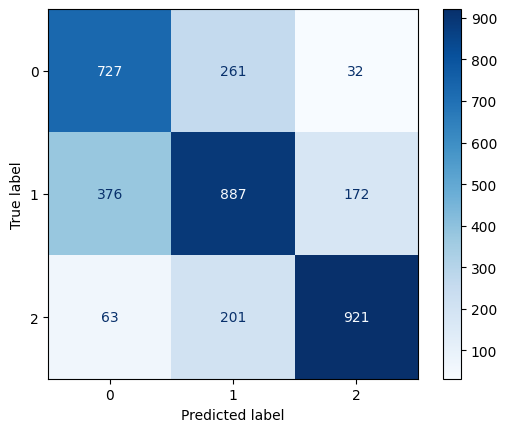

,precision,recall,f1-score,support
0,0.623499,0.712745,0.665142,1020.000000
1,0.657524,0.618118,0.637213,1435.000000
2,0.818667,0.777215,0.797403,1185.000000
accuracy,0.696429,0.696429,0.696429,0.696429
macro avg,0.699897,0.702693,0.699919,3640.000000
weighted avg,0.700450,0.696429,0.697189,3640.000000


AUC-ROC test: 0.8765
AUC-ROC train: 0.9558


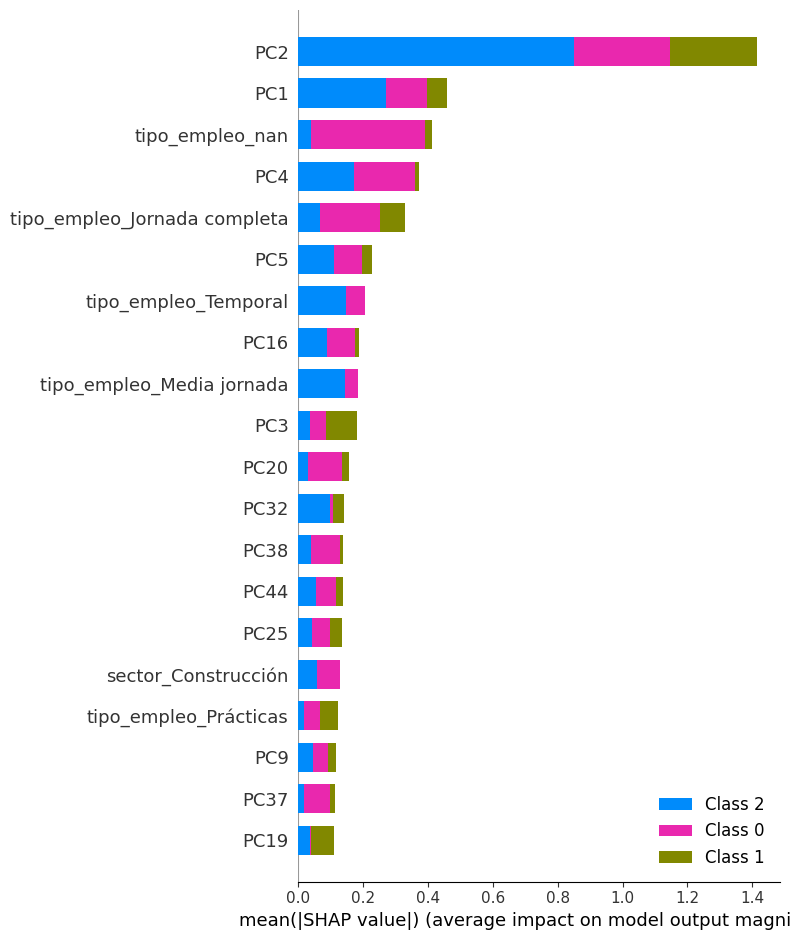

In [65]:
lgbm_set1 = joblib.load('../models/seniority/set_1_LGBMClassifier.joblib')
resultados(lgbm_set1, X_train[sets_posibles[0]], X_test[sets_posibles[0]])

El tipo de empleo nulo lo toma como variable importante, aunque también aparece temporal, jornada completa, media jornada...

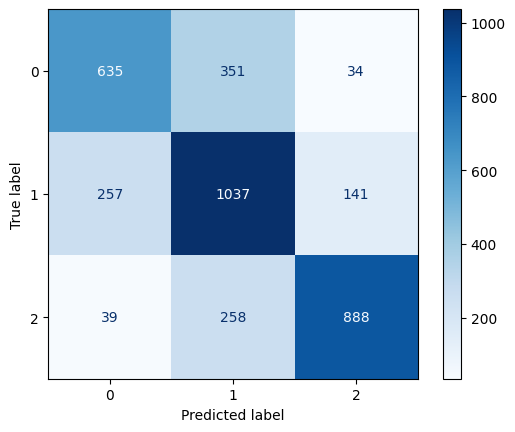

,precision,recall,f1-score,support
0,0.682062,0.622549,0.650948,1020.000000
1,0.630012,0.722648,0.673158,1435.000000
2,0.835372,0.749367,0.790036,1185.000000
accuracy,0.703297,0.703297,0.703297,0.703297
macro avg,0.715815,0.698188,0.704714,3640.000000
weighted avg,0.711452,0.703297,0.704984,3640.000000


AUC-ROC test: 0.8734
AUC-ROC train: 0.9349


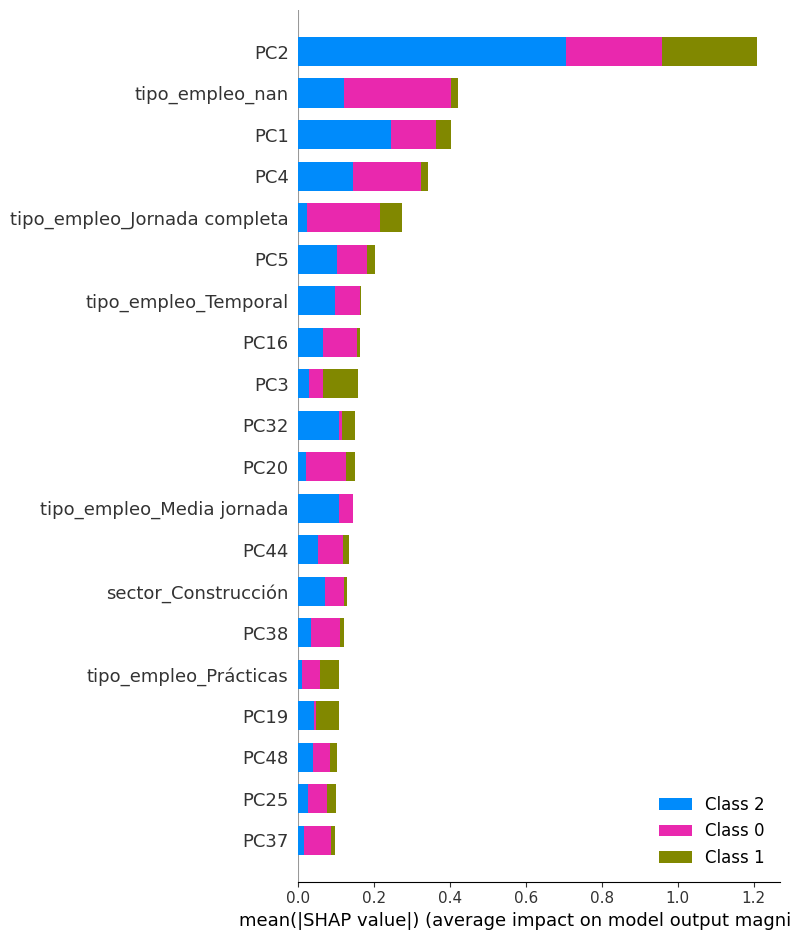

In [66]:
xgb_set1 = joblib.load('../models/seniority/set_1_XGBClassifier.joblib') 
resultados(xgb_set1, X_train[sets_posibles[0]], X_test[sets_posibles[0]])

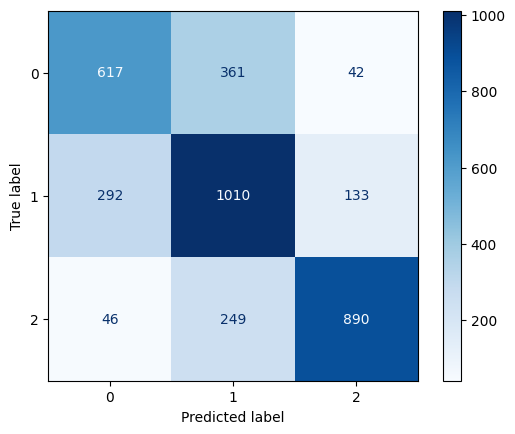

,precision,recall,f1-score,support
0,0.646073,0.604902,0.624810,1020.000000
1,0.623457,0.703833,0.661211,1435.000000
2,0.835681,0.751055,0.791111,1185.000000
accuracy,0.691484,0.691484,0.691484,0.691484
macro avg,0.701737,0.686597,0.692377,3640.000000
weighted avg,0.698884,0.691484,0.693300,3640.000000


AUC-ROC test: 0.8626
AUC-ROC train: 0.9349


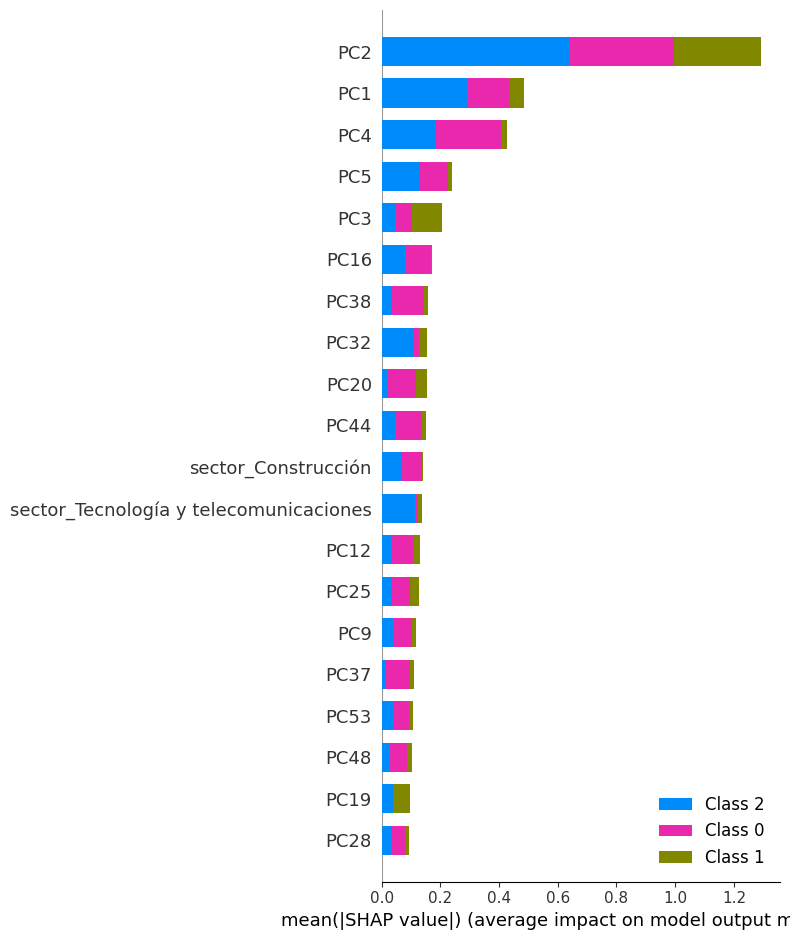

In [67]:
xgb_set2 = joblib.load('../models/seniority/set_2_XGBClassifier.joblib')
resultados(xgb_set2, X_train[sets_posibles[1]], X_test[sets_posibles[1]])

In [68]:
import json
with open('../artifacts/seniority/feature_columns.json', 'w') as f:
    json.dump(list(X_train.columns), f)

En el caso del seniority, aunque toma alta importancia el tipo de empleo como nulo, es una variable que si que aporta más información, por lo que el modelo que mejor me esta funcionando es el XGBClassifier con el set 1. Ya que tiene menos overfitting que el LGBM.

In [70]:
joblib.dump(xgb_set1, '../models/seniority/best_model.joblib')

['../models/seniority/best_model.joblib']